# LeetCode #433: Minimum Genetic Mutation

https://leetcode.com/problems/minimum-genetic-mutation/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (DFS/backtracking over all paths)** | $O(N! \cdot L)$ | $O(N)$ |
| **BFS (shortest path in mutation graph)** | $O(N^2 \cdot L)$ | $O(N)$ |

---

## Understanding the Methods

### Brute Force (DFS/backtracking over all paths)
Explore every possible sequence of mutations via DFS. Revisiting the same gene strings leads to cycles and exponential blowup. Even with a visited set, DFS may find a long path before a short one and can't guarantee it found the shortest.

### Optimal: BFS (shortest path in mutation graph) ★
Model the bank as a graph where two gene strings are connected if they differ by exactly one character. BFS from `startGene` guarantees the first time `endGene` is reached equals the minimum number of mutations. At each step, try all bank strings reachable in one mutation (differ by 1 char) and not yet visited.

**Why this is better than Brute Force:** BFS explores level by level — each level is one more mutation. The moment `endGene` appears in any level, that level number is the answer. No DFS backtracking or path tracking needed.

**Constraints:**
* 0 <= bank.length <= 10
* startGene.length == endGene.length == bank[i].length == 8
* startGene, endGene, bank[i] consist of 'A', 'C', 'G', 'T'

## Solutions

### C#

In [ ]:
public class Solution {
    public int MinMutation(string startGene, string endGene, string[] bank) {
        var bankSet = new HashSet<string>(bank);
        if (!bankSet.Contains(endGene)) return -1;

        var queue = new Queue<string>();
        var visited = new HashSet<string> { startGene };
        queue.Enqueue(startGene);
        int mutations = 0;

        while (queue.Count > 0) {
            mutations++;
            int levelSize = queue.Count;
            for (int i = 0; i < levelSize; i++) {
                string current = queue.Dequeue();
                foreach (string next in bankSet) {
                    // One mutation = exactly one character different
                    if (!visited.Contains(next) && DiffByOne(current, next)) {
                        if (next == endGene) return mutations;
                        visited.Add(next);
                        queue.Enqueue(next);
                    }
                }
            }
        }
        return -1;
    }

    private bool DiffByOne(string a, string b) {
        int diff = 0;
        for (int i = 0; i < a.Length; i++)
            if (a[i] != b[i] && ++diff > 1) return false;
        return diff == 1;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def minMutation(self, startGene: str, endGene: str, bank: list[str]) -> int:
        bank_set = set(bank)
        if endGene not in bank_set:
            return -1

        queue = deque([startGene])
        visited = {startGene}
        mutations = 0

        while queue:
            mutations += 1
            for _ in range(len(queue)):
                current = queue.popleft()
                for nxt in bank_set:
                    # One mutation = exactly one character different
                    if nxt not in visited and sum(a != b for a, b in zip(current, nxt)) == 1:
                        if nxt == endGene:
                            return mutations
                        visited.add(nxt)
                        queue.append(nxt)
        return -1

### Go

In [ ]:
func minMutation(startGene string, endGene string, bank []string) int {
    bankSet := make(map[string]bool)
    for _, g := range bank {
        bankSet[g] = true
    }
    if !bankSet[endGene] {
        return -1
    }

    queue := []string{startGene}
    visited := map[string]bool{startGene: true}
    mutations := 0

    for len(queue) > 0 {
        mutations++
        size := len(queue)
        for i := 0; i < size; i++ {
            current := queue[0]
            queue = queue[1:]
            for next := range bankSet {
                // One mutation = exactly one character different
                if !visited[next] && diffByOne(current, next) {
                    if next == endGene {
                        return mutations
                    }
                    visited[next] = true
                    queue = append(queue, next)
                }
            }
        }
    }
    return -1
}

func diffByOne(a, b string) bool {
    diff := 0
    for i := 0; i < len(a); i++ {
        if a[i] != b[i] {
            diff++
            if diff > 1 {
                return false
            }
        }
    }
    return diff == 1
}

### Rust

In [ ]:
use std::collections::{HashSet, VecDeque};

impl Solution {
    pub fn min_mutation(start_gene: String, end_gene: String, bank: Vec<String>) -> i32 {
        let bank_set: HashSet<&str> = bank.iter().map(|s| s.as_str()).collect();
        if !bank_set.contains(end_gene.as_str()) {
            return -1;
        }

        let mut queue: VecDeque<String> = VecDeque::new();
        let mut visited: HashSet<String> = HashSet::new();
        queue.push_back(start_gene.clone());
        visited.insert(start_gene);
        let mut mutations = 0;

        while !queue.is_empty() {
            mutations += 1;
            let level_size = queue.len();
            for _ in 0..level_size {
                let current = queue.pop_front().unwrap();
                for next in &bank {
                    // One mutation = exactly one character different
                    if !visited.contains(next) && Self::diff_by_one(&current, next) {
                        if next == &end_gene {
                            return mutations;
                        }
                        visited.insert(next.clone());
                        queue.push_back(next.clone());
                    }
                }
            }
        }
        -1
    }

    fn diff_by_one(a: &str, b: &str) -> bool {
        a.chars().zip(b.chars()).filter(|(x, y)| x != y).count() == 1
    }
}

## Example Scenarios

**1. Common Case**
**Input:** start="AACCGGTT", end="AAACGGTA", bank=["AACCGGTA","AACCGCTA","AAACGGTA"]
BFS level 1: from "AACCGGTT", check bank — "AACCGGTA" differs by 1 (T→A at pos 7) → enqueue. Level 2: from "AACCGGTA", check bank — "AAACGGTA" differs by 1 (C→A at pos 2) → matches end → return 2.

**2. Slightly Complex**
**Input:** start="AACCGGTT", end="AACCGGTA", bank=["AACCGGTA"]
BFS level 1: "AACCGGTA" is in bank, differs by 1 from start, equals end → return 1. Minimum possible non-zero mutation count; the answer is 1 since start and end differ by exactly one character and the one-step intermediate is valid.

**3. Edge Case: Time Factor**
**Input:** bank has 10 strings, none reachable from start.
BFS explores all 10 bank strings per level for each queued string. With $N=10$ and string length $L=8$: each `DiffByOne` check is $O(L)=O(8)$; across all queue states the total work is $O(N^2 \cdot L) = O(10^2 \cdot 8) = O(800)$. The queue eventually empties; return -1.

**4. Edge Case: Space Factor**
**Input:** bank has 10 strings forming a linear chain: start→b₁→b₂→…→b₁₀=end.
The visited set holds at most $N+1=11$ strings (start + 10 bank strings). The queue at any point holds at most one level's worth of strings — also bounded by $N$. Total space $O(N)$; this is the worst case for the visited set.

**5. Almost-Impossible but Plausible**
**Input:** end="AACCGGTT" not in bank.
The `bankSet.Contains(endGene)` guard fires immediately before any BFS — return -1. Without this guard, BFS would still terminate correctly (never dequeue the target), but would waste $O(N^2 \cdot L)$ work. The guard makes it $O(N)$ for the set construction.

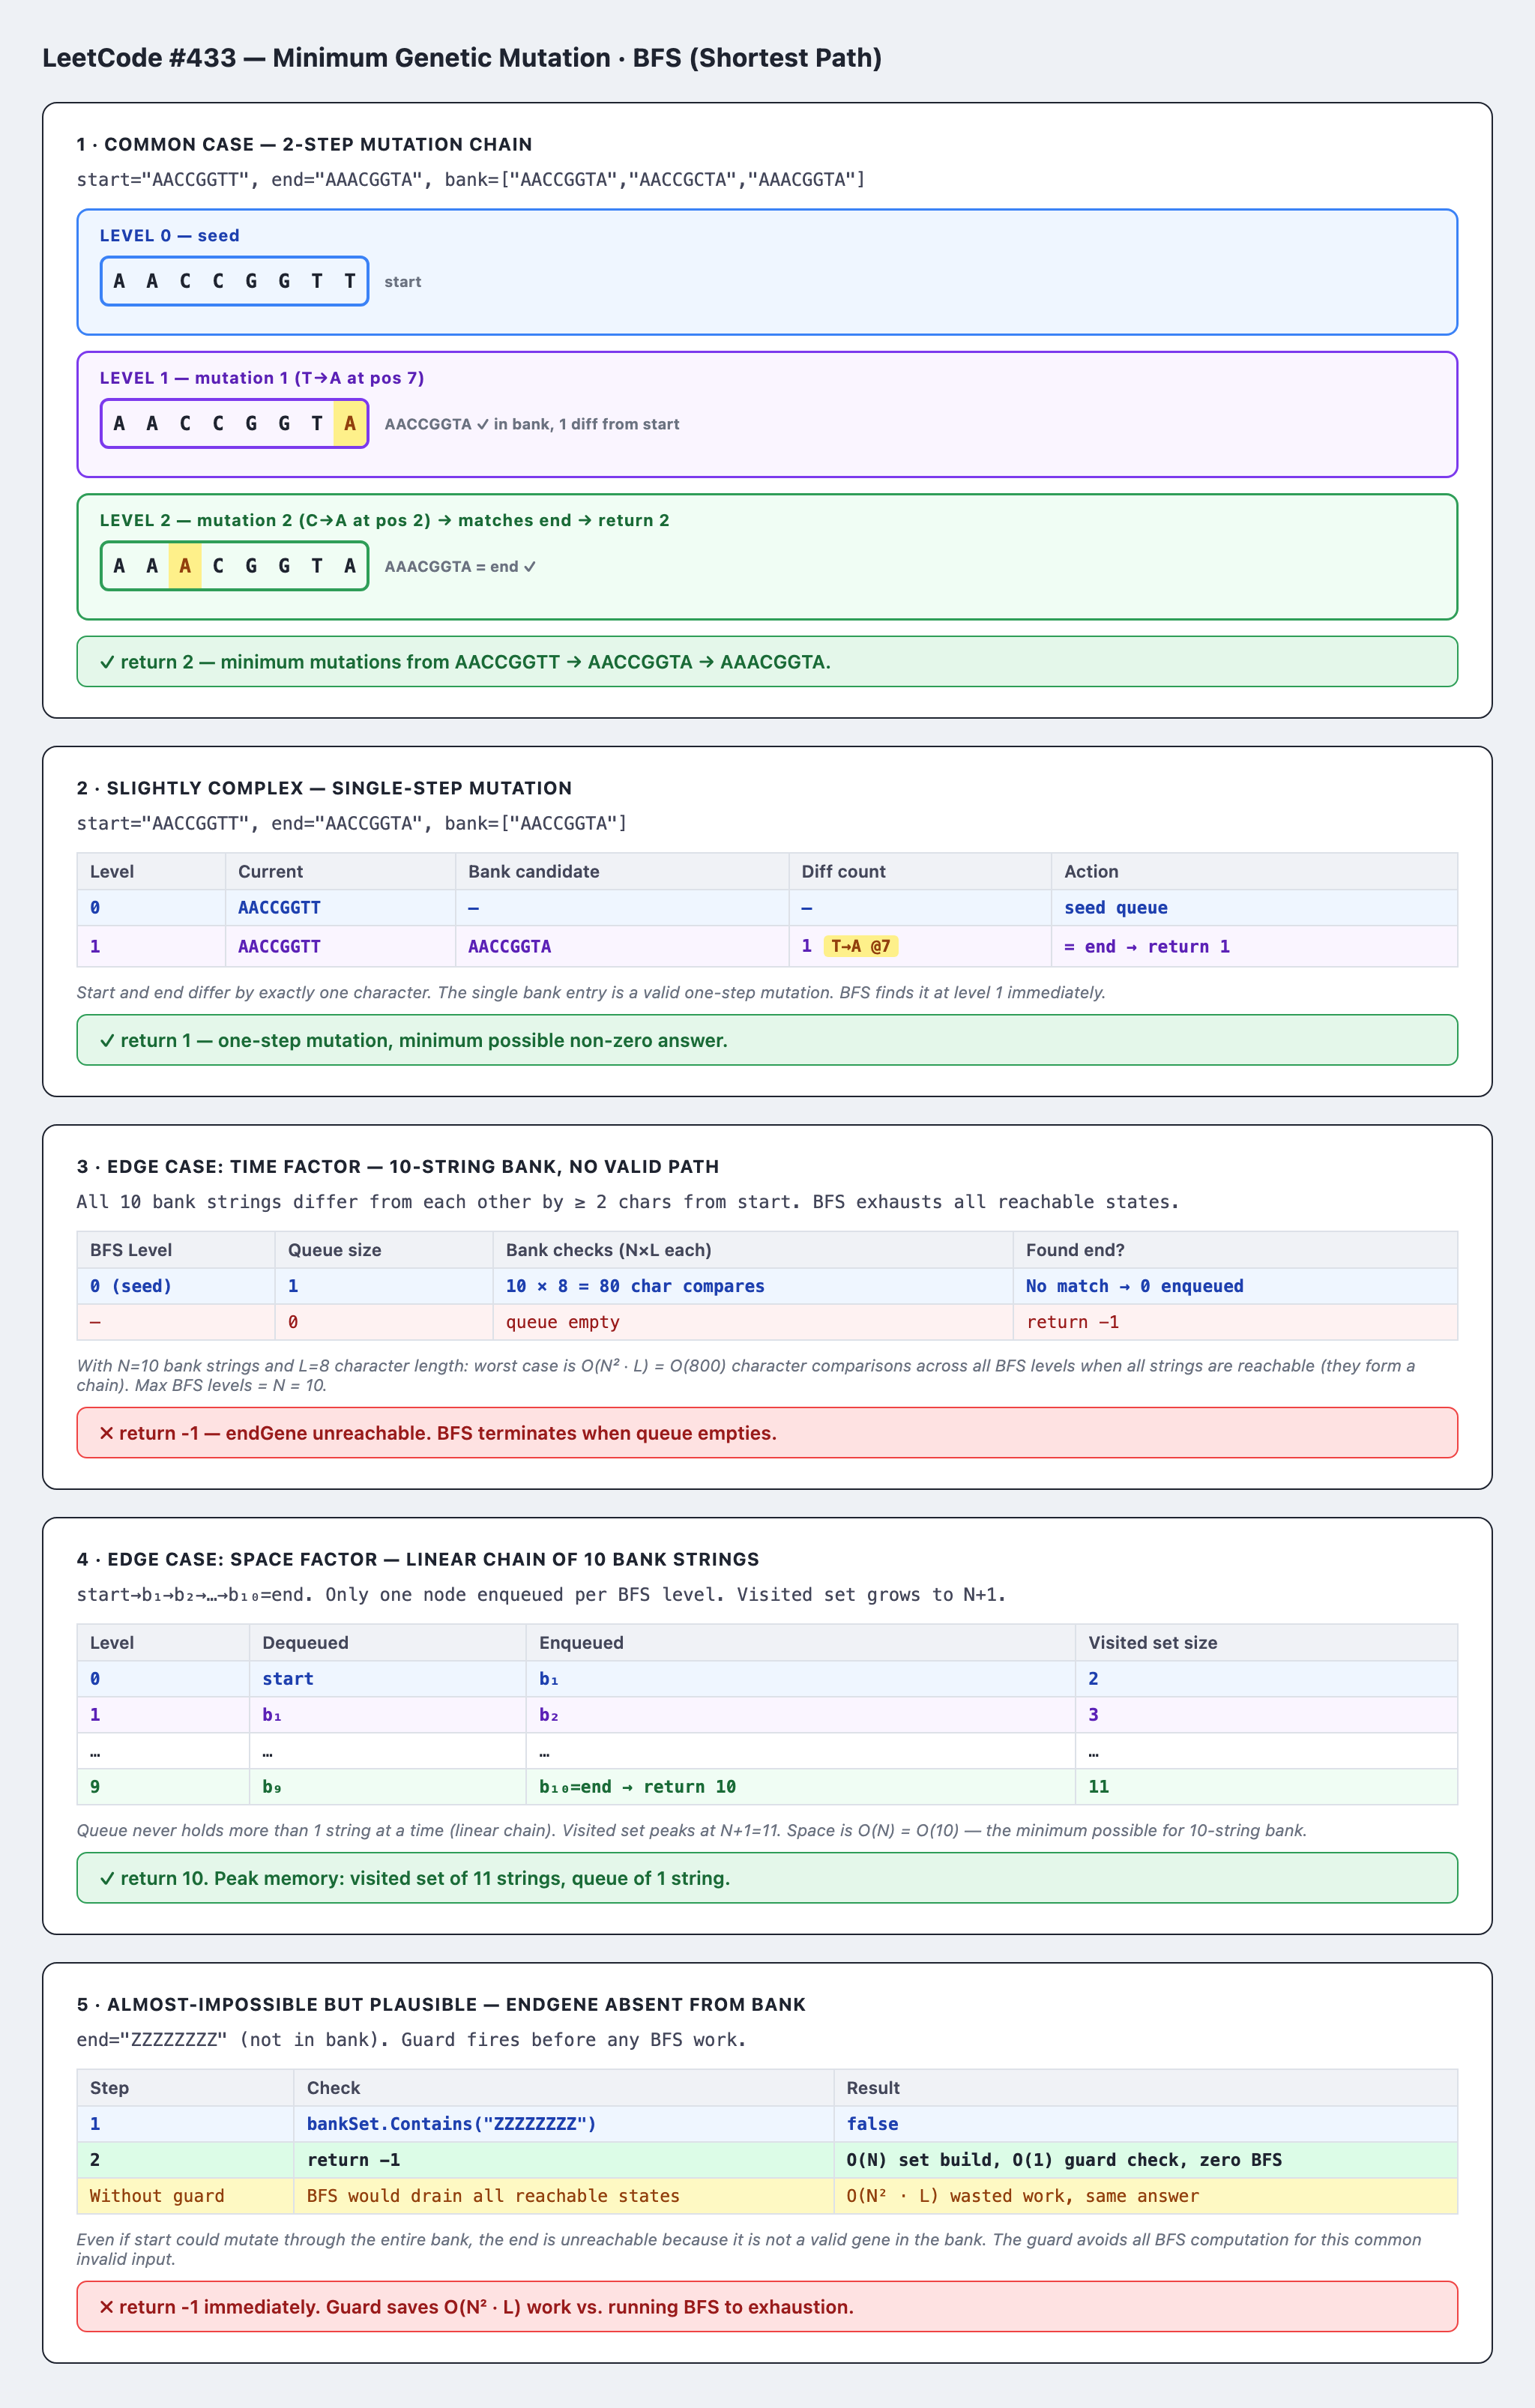